# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Dandi Darmansyah
- Email: dandidarmansyah8@gmail.com
- Id Dicoding: Dandi Darmansyah

## Persiapan

### Menyiapkan library yang dibutuhkan

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

import joblib

### Menyiapkan data yang akan diguankan

## Data Understanding

In [124]:
df = pd.read_csv("/content/employee_data.csv")
df

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,1466,38,0.0,Travel_Rarely,168,Research & Development,1,3,Life Sciences,1,...,4,80,0,10,4,4,1,0,0,0
1466,1467,50,NaN,Travel_Rarely,813,Research & Development,17,5,Life Sciences,1,...,3,80,3,19,3,3,14,11,1,11
1467,1468,28,1.0,Travel_Rarely,1485,Research & Development,12,1,Life Sciences,1,...,4,80,0,1,4,2,1,1,0,0
1468,1469,40,0.0,Non-Travel,458,Research & Development,16,2,Life Sciences,1,...,2,80,1,6,0,3,4,2,0,0


In [125]:
display(df.shape)
display(df.head())
display(df.info())
display(df.describe())

(1470, 35)

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

None

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### Data Preparation / Preprocessing

In [126]:
# mengecek missing value
missingValues = df.isnull().sum()

# megecek data duplikat
dataDuplicate = df.duplicated().sum()

display(missingValues)
display(dataDuplicate)

,0
EmployeeId,0
Age,0
Attrition,412
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


np.int64(0)

In [127]:
# menghapus data nan
df.dropna(subset=['Attrition'], inplace=True)

In [128]:
print(df.columns)

Index(['EmployeeId', 'Age', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


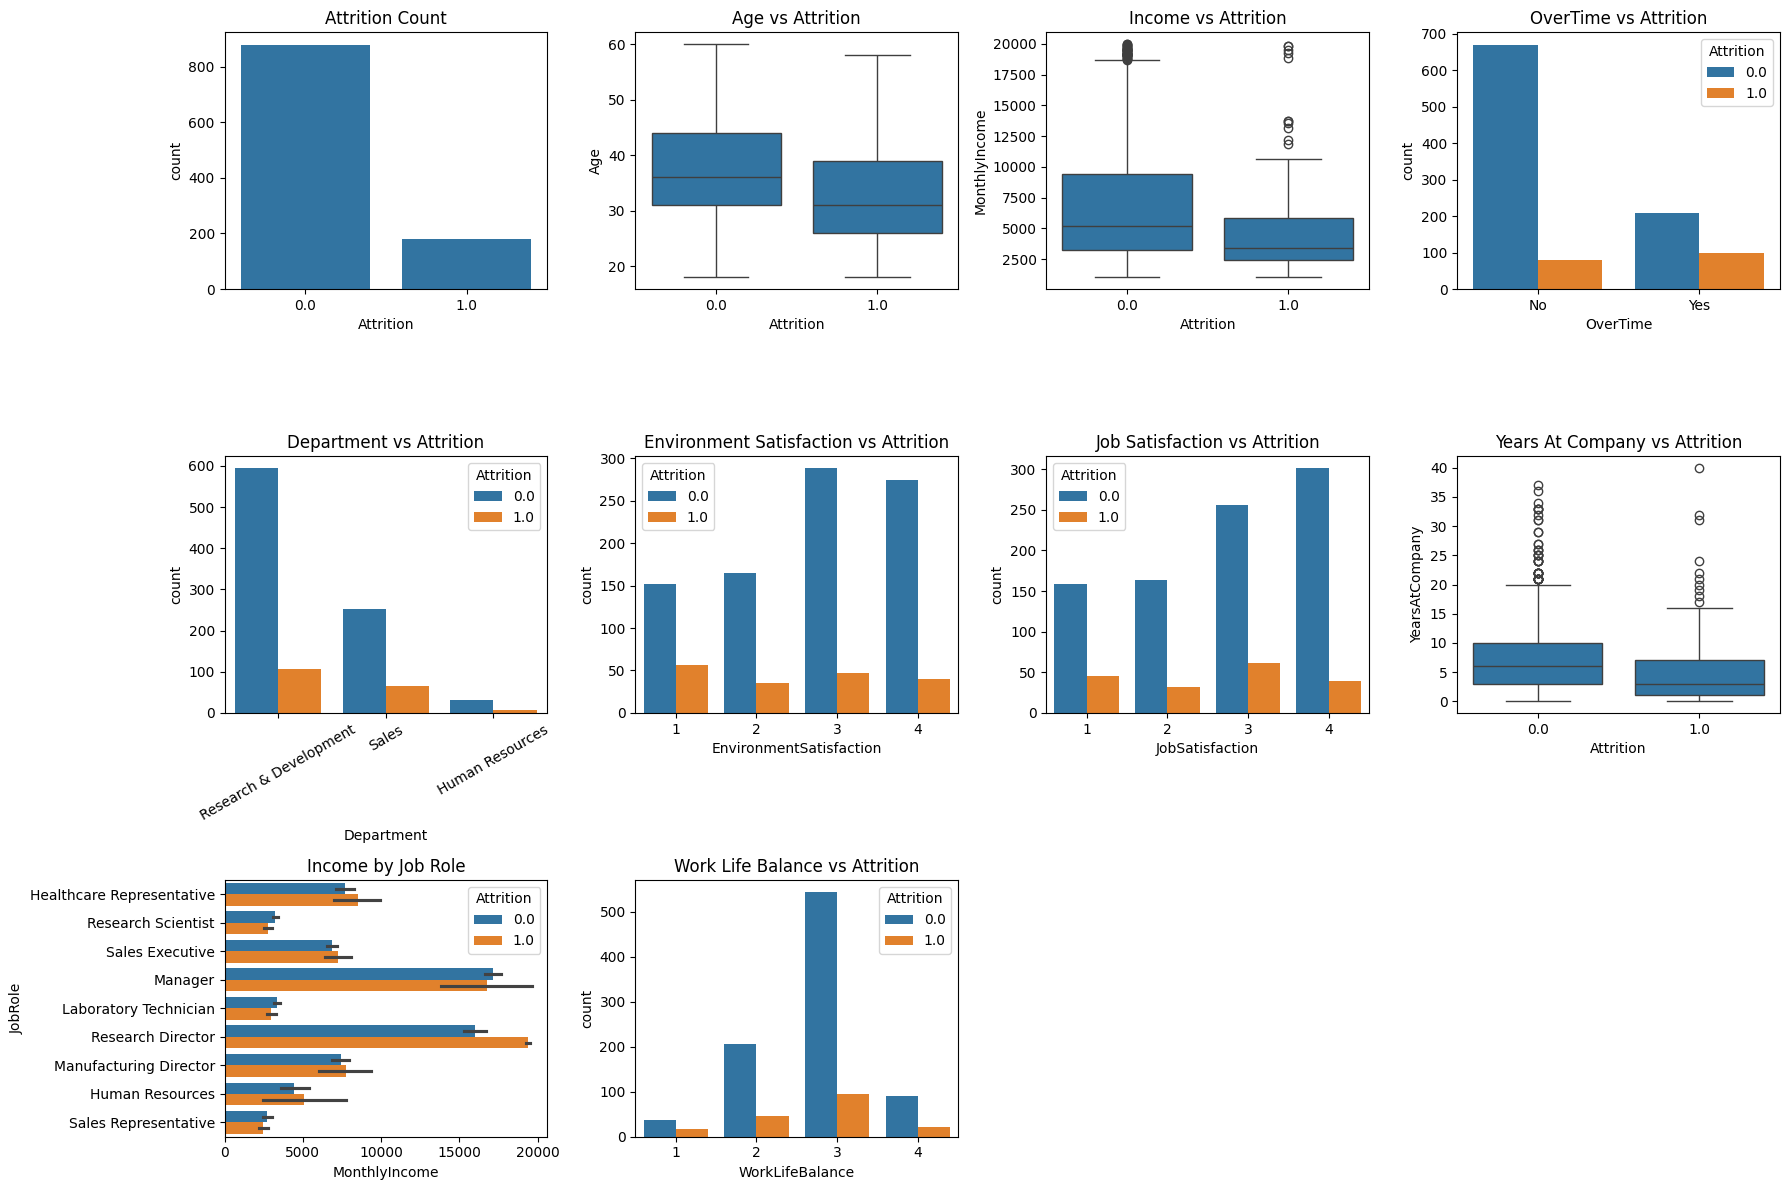

In [129]:
plt.figure(figsize=(18, 12))

# 1. Attrition
plt.subplot(3, 4, 1)
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Count')

# 2. Age vs Attrition
plt.subplot(3, 4, 2)
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title('Age vs Attrition')

# 3. Income vs Attrition
plt.subplot(3, 4, 3)
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Income vs Attrition')

# 4. OverTime
plt.subplot(3, 4, 4)
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('OverTime vs Attrition')

# 5. Department
plt.subplot(3, 4, 5)
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title('Department vs Attrition')
plt.xticks(rotation=30)

# 6. Environment Satisfaction
plt.subplot(3, 4, 6)
sns.countplot(x='EnvironmentSatisfaction', hue='Attrition', data=df)
plt.title('Environment Satisfaction vs Attrition')

# 7. Job Satisfaction (FIXED: sebelumnya salah label)
plt.subplot(3, 4, 7)
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.title('Job Satisfaction vs Attrition')

# 8. Years At Company (FIXED: salah pakai boxplot)
plt.subplot(3, 4, 8)
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title('Years At Company vs Attrition')

# 9. Job Role vs Income
plt.subplot(3, 4, 9)
sns.barplot(x='MonthlyIncome', y='JobRole', hue='Attrition', data=df)
plt.title('Income by Job Role')

# 10. Work Life Balance
plt.subplot(3, 4, 10)
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df)
plt.title('Work Life Balance vs Attrition')

plt.tight_layout()
plt.show()

In [130]:
# Ambil kolom numerik
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns

# Simpan hasil dalam dictionary (biar mudah dipakai lagi)
outlier_summary = {}

print("HASIL DETEKSI OUTLIER (IQR)\n")

for col in numeric_features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1

    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    count = ((df[col] < low) | (df[col] > high)).sum()

    # simpan ke dictionary
    outlier_summary[col] = {
        'count': count,
        'low': low,
        'high': high
    }

    # print hasil
    print(f"{col}")
    print(f"  Range   : {low:.2f} - {high:.2f}")
    print(f"  Mean    : {df[col].mean():.2f}")
    print(f"  Median  : {df[col].median():.2f}")
    print(f"  Std Dev : {df[col].std():.2f}")
    print(f"  Outlier : {count}")
    print("  Status  :", "Ada outlier" if count > 0 else "Tidak ada outlier")
    print("-" * 40)


HASIL DETEKSI OUTLIER (IQR)

EmployeeId
  Range   : -766.00 - 2248.00
  Mean    : 736.66
  Median  : 731.50
  Std Dev : 427.44
  Outlier : 0
  Status  : Tidak ada outlier
----------------------------------------
Age
  Range   : 10.50 - 62.50
  Mean    : 37.06
  Median  : 36.00
  Std Dev : 9.41
  Outlier : 0
  Status  : Tidak ada outlier
----------------------------------------
Attrition
  Range   : 0.00 - 0.00
  Mean    : 0.17
  Median  : 0.00
  Std Dev : 0.38
  Outlier : 179
  Status  : Ada outlier
----------------------------------------
DailyRate
  Range   : -589.62 - 2223.38
  Mean    : 809.54
  Median  : 817.50
  Std Dev : 408.48
  Outlier : 0
  Status  : Tidak ada outlier
----------------------------------------
DistanceFromHome
  Range   : -14.50 - 29.50
  Mean    : 8.98
  Median  : 7.00
  Std Dev : 8.04
  Outlier : 0
  Status  : Tidak ada outlier
----------------------------------------
Education
  Range   : -1.00 - 7.00
  Mean    : 2.88
  Median  : 3.00
  Std Dev : 1.03
  Outl

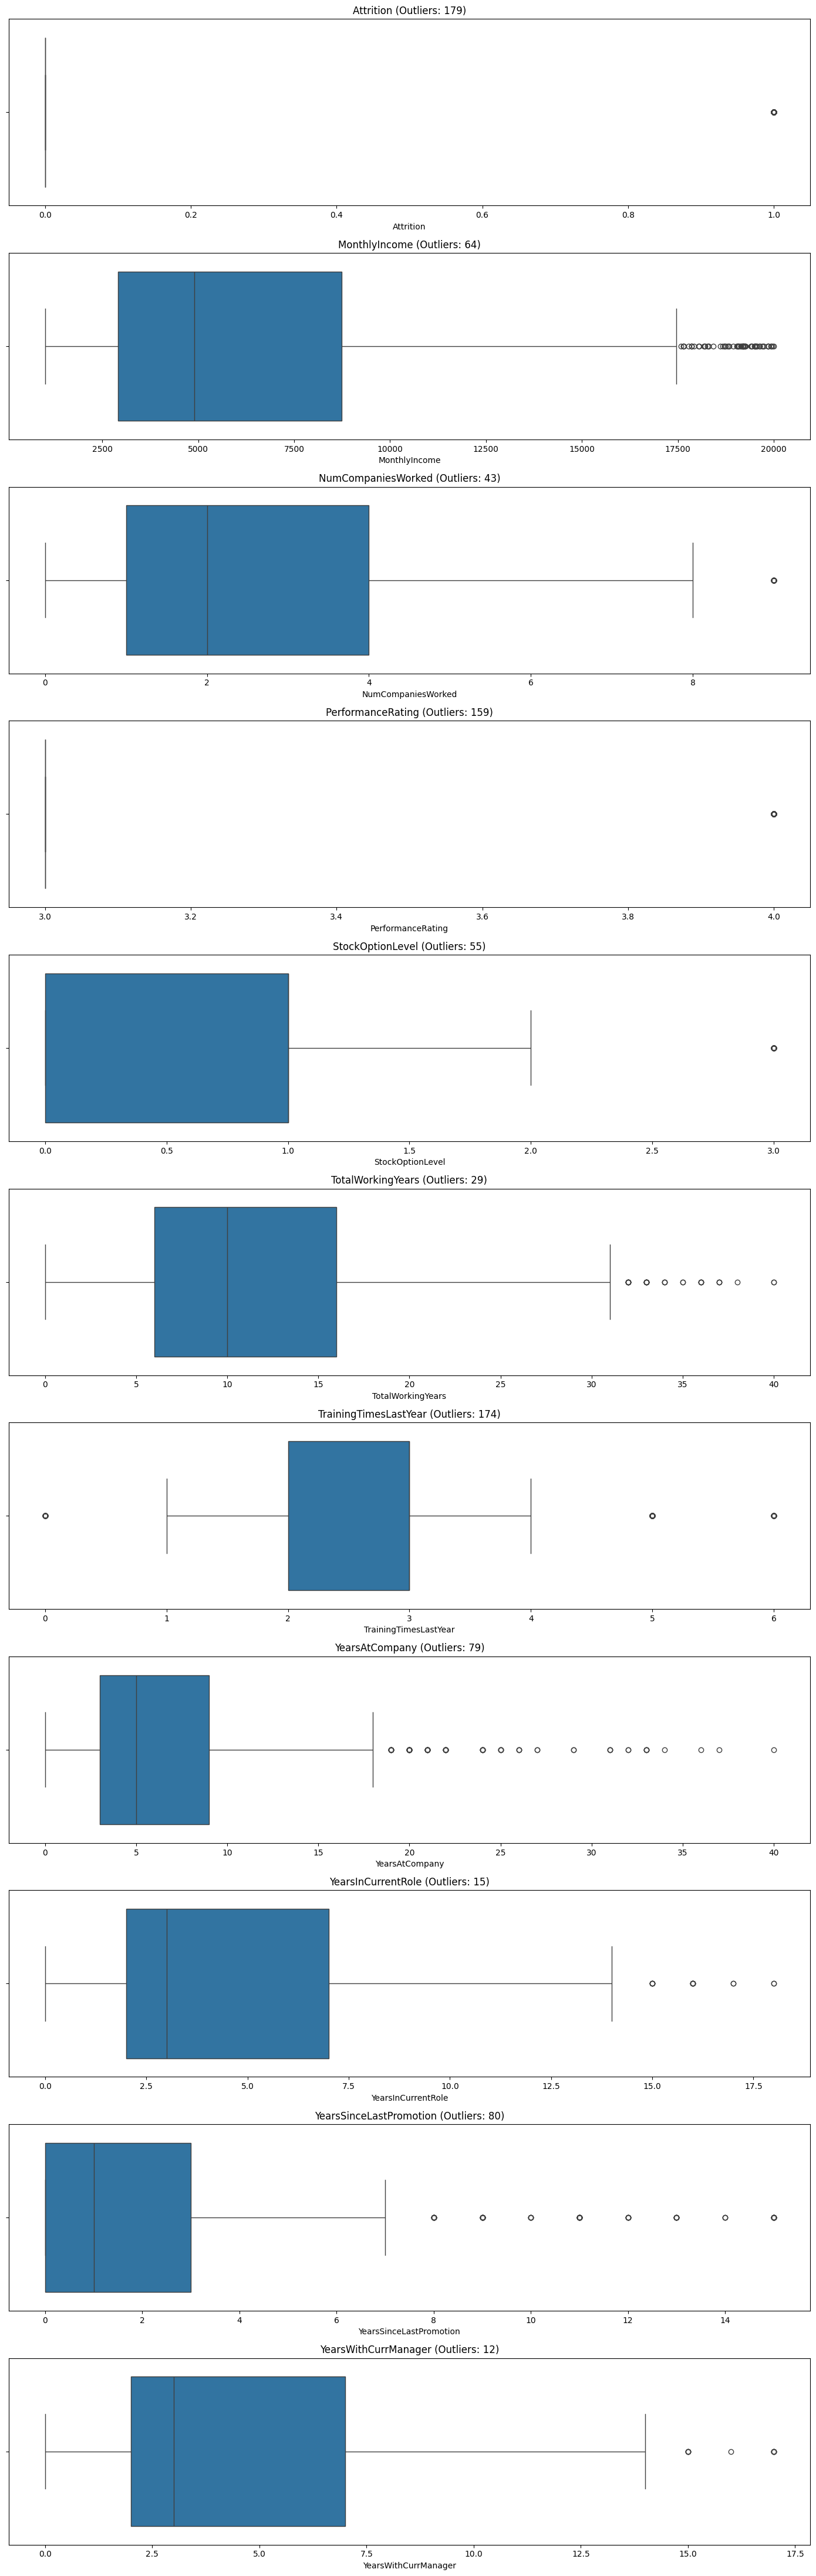

In [131]:
selected_cols = [c for c in outlier_summary if outlier_summary[c]['count'] > 0]

n = len(selected_cols)

if n > 0:
    fig, axes = plt.subplots(n, 1, figsize=(14, 4*n))

    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, selected_cols):
        sns.boxplot(data=df, x=col, ax=ax)
        ax.set_title(f"{col} (Outliers: {outlier_summary[col]['count']})")

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada outlier untuk divisualisasikan")

In [132]:
# menghapus kolom yang tidak digunakan
df = df.drop(['EmployeeId', 'EmployeeCount', 'StandardHours', 'Over18'], axis=1)

In [133]:
df.to_csv("attrition_dashboard_data.csv", index=False)

## Modeling

In [134]:
# SPLIT FEATURE & TARGET
X = df.drop('Attrition', axis=1)
y = df['Attrition']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
ordinal_cols = []
nominal_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('ord', OrdinalEncoder(), ordinal_cols),
        ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols)
    ]
)

# PIPELINE
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

In [135]:
from sklearn.utils import resample
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_df = pd.concat([X_train, y_train], axis=1)

majority = train_df[train_df.Attrition == 0]
minority = train_df[train_df.Attrition == 1]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

train_upsampled = pd.concat([majority, minority_upsampled])

In [136]:
# Train model
pipeline.fit(X_train, y_train)

# Predict & evaluate
y_pred = pipeline.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      0.72      0.81       176
         1.0       0.35      0.72      0.47        36

    accuracy                           0.72       212
   macro avg       0.64      0.72      0.64       212
weighted avg       0.83      0.72      0.75       212

Confusion Matrix:
 [[127  49]
 [ 10  26]]


In [137]:
joblib.dump(pipeline, 'model_attrition.pkl')

['model_attrition.pkl']

## Evaluation

Test Accuracy: 0.7217


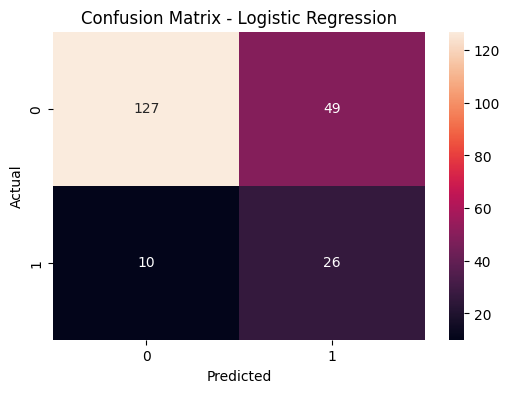

In [138]:
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## CONCLUSION

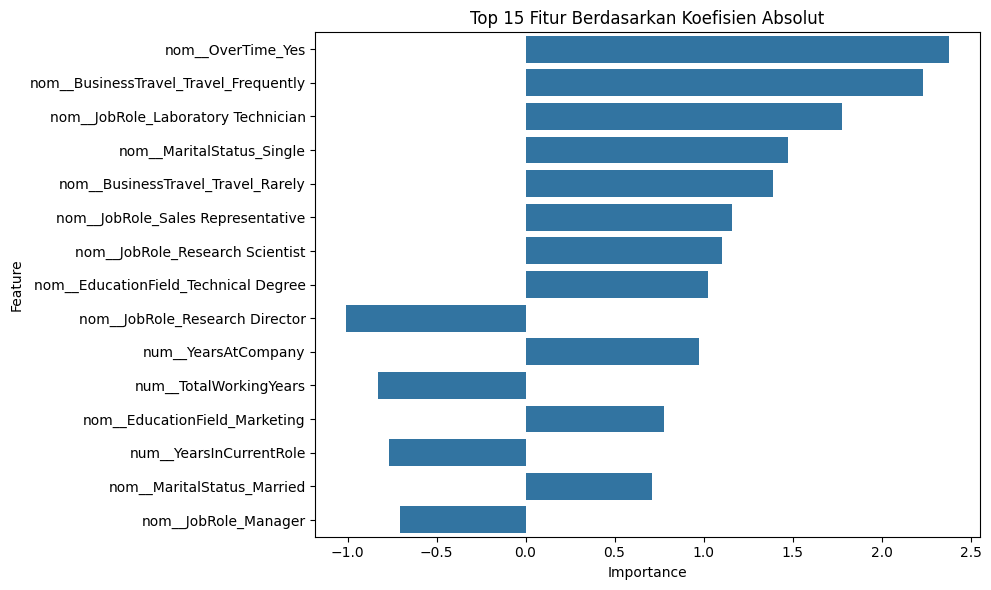

In [140]:
# 1. Ambil nama fitur dari preprocessing
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()
importances = pipeline.named_steps['classifier'].coef_[0]

# 3. Buat DataFrame
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. Tambahkan kolom nilai absolut
feat_imp['Abs_Importance'] = feat_imp['Importance'].abs()
feat_imp = feat_imp.sort_values(by='Abs_Importance', ascending=False)

# 5. Visualisasi
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature')
plt.title('Top 15 Fitur Berdasarkan Koefisien Absolut')
plt.tight_layout()
plt.show()

Berdasarkan grafik tersebut, faktor Lembur (**OverTime_Yes**) dan Frekuensi Perjalanan Bisnis (**BusinessTravel_Frequently**) muncul sebagai indikator paling dominan yang memengaruhi prediksi model, disusul oleh peran pekerjaan spesifik seperti Laboratory Technician dan status Single. Tingginya koefisien pada variabel lembur menunjukkan bahwa beban kerja berlebih merupakan pemicu utama dalam data Anda, sementara munculnya variabel masa kerja (seperti **YearsAtCompany**) di posisi menengah mengindikasikan bahwa loyalitas karyawan turut berperan namun pengaruhnya tidak sekuat faktor lingkungan kerja dan jenis peran jabatan. Kesimpulannya, strategi intervensi sebaiknya diprioritaskan pada peninjauan ulang kebijakan lembur dan manajemen beban kerja untuk posisi-posisi teknis guna menjaga stabilitas organisasi.


